1) Declaración variables.
2) Funciones principales.
def nb_quantum(x,V0,psi,m,...):
 return el xurro de funcion.

 def  nb_classical(x,V0,psi,m,...):
 return el xurro de funcion.

 def tun_quantum(V0,psi,m,...):
 return el xurro de funcion.

 def tun_classical(Vo,psi,m):
 return ....


 3) Definir el running de x
 x = np.linspace(0.01,0.9,1000)
 nbq = []
 nbc = []
 for i in x:
        if i <= 0.5:
            nbq.append( np.log(nb_quantum(i,....)) )
        if i >= 0.5
           nbc.append(np.( nb_classical(i,...)))
                 

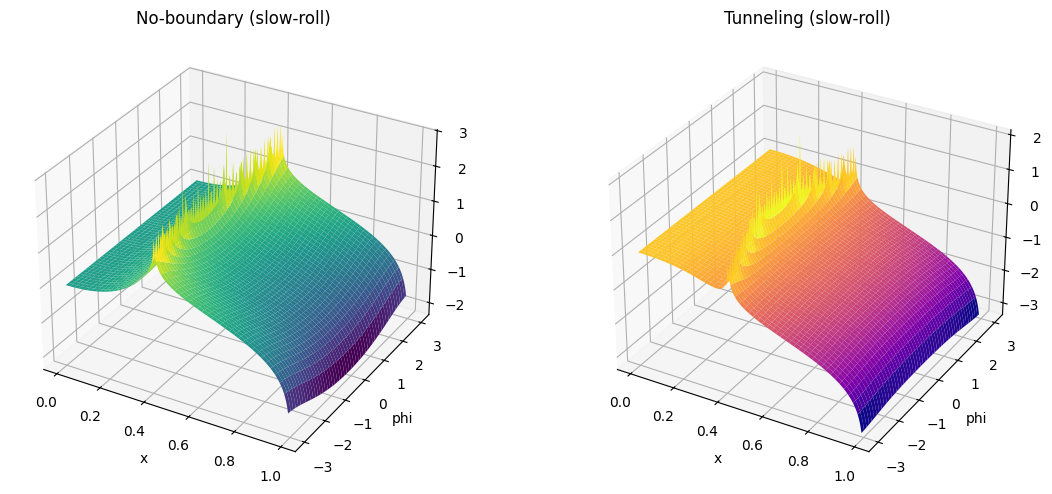

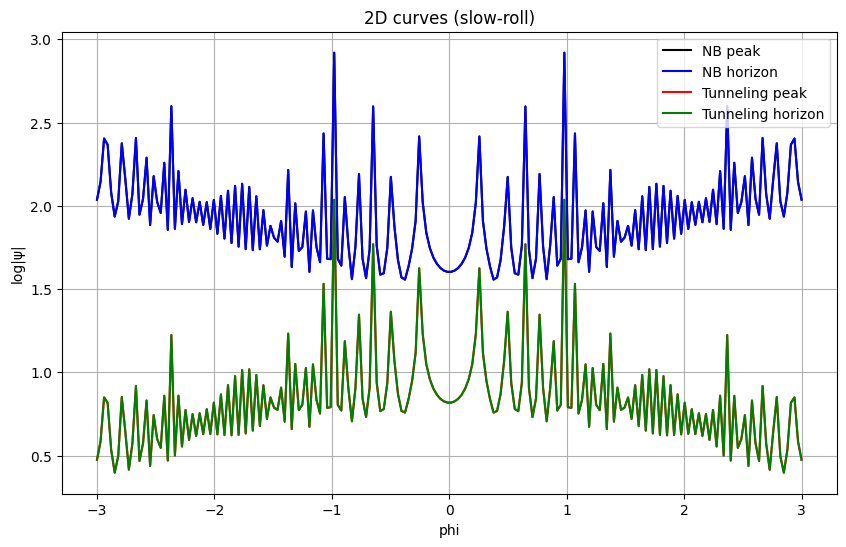

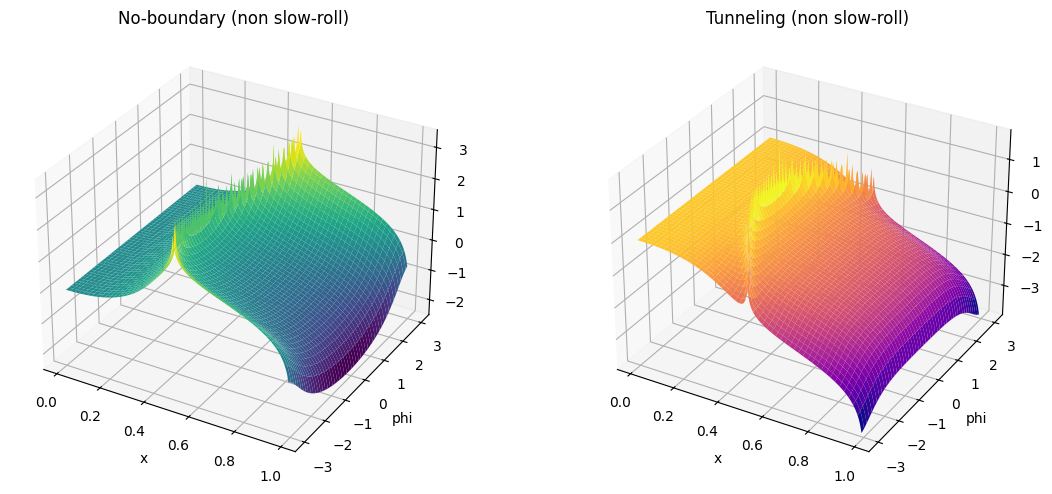

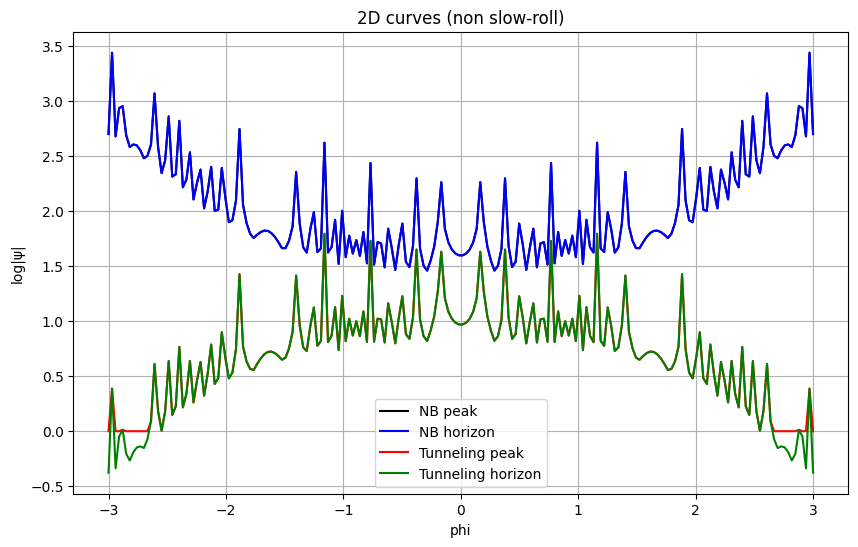

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================
Delta = 1.0
phi_vals = np.linspace(-3, 3, 200)
x_vals = np.linspace(0.01, 0.99, 400)

X, PHI = np.meshgrid(x_vals, phi_vals)

# =========================
# POTENTIAL + HUBBLE
# =========================
def V(phi, V0, m, Delta):
    return V0 + m * (1 + np.cos(phi / Delta))

def H(phi, V0, m, Delta):
    return np.sqrt(V(phi, V0, m, Delta))


# =========================
# CORE FUNCTION A(x,phi)
# =========================
def compute_A(X, PHI, V0, m, Delta):
    Hvals = H(PHI, V0, m, Delta)
    return (Hvals**2 * X**2) / (1 - X)**2


# =========================
# NO-BOUNDARY WAVEFUNCTION
# =========================
def psi_no_boundary(X, PHI, V0, m, Delta):
    Hvals = H(PHI, V0, m, Delta)
    A = compute_A(X, PHI, V0, m, Delta)

    psi = np.zeros_like(X, dtype=complex)

    # Quantum region
    mask_q = A < 1
    Aq = A[mask_q]
    Hq = Hvals[mask_q]

    psi[mask_q] = (
        1 / (1 - Aq)**(1/4)
        * np.exp((np.pi/(2*Hq**2)) * (1 - (1 - Aq)**(3/2)))
    )

    # Classical region
    mask_c = A >= 1
    Ac = A[mask_c]
    Hc = Hvals[mask_c]

    psi[mask_c] = (
        1 / (Ac - 1)**(1/4)
        * np.exp(np.pi/(2*Hc**2))
        * np.exp(1j * np.pi/(2*Hc**2) * (Ac - 1)**(3/2))
    )

    return psi


# =========================
# TUNNELING WAVEFUNCTION
# =========================
def psi_tunneling(X, PHI, V0, m, Delta):
    Hvals = H(PHI, V0, m, Delta)
    A = compute_A(X, PHI, V0, m, Delta)

    psi = np.zeros_like(X, dtype=complex)

    # Quantum region
    mask_q = A < 1
    Aq = A[mask_q]
    Hq = Hvals[mask_q]

    psi[mask_q] = (
        1 / (1 - Aq)**(1/4)
        * np.exp(-(np.pi/(2*Hq**2)) * (1 - (1 - Aq)**(3/2)))
    )

    # Classical region
    mask_c = A >= 1
    Ac = A[mask_c]
    Hc = Hvals[mask_c]

    psi[mask_c] = (
        1 / (Ac - 1)**(1/4)
        * np.exp(-np.pi/(2*Hc**2))
        * np.exp(1j * np.pi/(2*Hc**2) * (Ac - 1)**(3/2))
    )

    return psi


# =========================
# EXTRACT PEAK + HORIZON
# =========================
def extract_curves(psi, X, PHI, V0, m, Delta):
    peak_vals = []
    horizon_vals = []

    for i in range(len(phi_vals)):
        row = np.abs(psi[i, :])

        # Peak
        peak_vals.append(np.max(row))

        # Horizon (A = 1)
        Hval = H(phi_vals[i], V0, m, Delta)
        A_vals = (Hval**2 * x_vals**2)/(1 - x_vals)**2

        idx = np.argmin(np.abs(A_vals - 1))
        horizon_vals.append(row[idx])

    return np.array(peak_vals), np.array(horizon_vals)


# =========================
# PLOT FUNCTION
# =========================
def plot_case(V0, m, title):
    psi_nb = psi_no_boundary(X, PHI, V0, m, Delta)
    psi_tun = psi_tunneling(X, PHI, V0, m, Delta)

    # -------- 3D PLOTS --------
    fig = plt.figure(figsize=(12,5))

    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(X, PHI, np.log(np.abs(psi_nb)+1e-12), cmap='viridis')
    ax1.set_title(f'No-boundary ({title})')
    ax1.set_xlabel('x')
    ax1.set_ylabel('phi')

    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(X, PHI, np.log(np.abs(psi_tun)+1e-12), cmap='plasma')
    ax2.set_title(f'Tunneling ({title})')
    ax2.set_xlabel('x')
    ax2.set_ylabel('phi')

    plt.tight_layout()
    plt.show()

    # -------- 2D CURVES --------
    peak_nb, horizon_nb = extract_curves(psi_nb, X, PHI, V0, m, Delta)
    peak_tun, horizon_tun = extract_curves(psi_tun, X, PHI, V0, m, Delta)

    plt.figure(figsize=(10,6))

    plt.plot(phi_vals, np.log(peak_nb), 'k', label='NB peak')
    plt.plot(phi_vals, np.log(horizon_nb), 'b', label='NB horizon')

    plt.plot(phi_vals, np.log(peak_tun), 'r', label='Tunneling peak')
    plt.plot(phi_vals, np.log(horizon_tun), 'g', label='Tunneling horizon')

    plt.title(f'2D curves ({title})')
    plt.xlabel('phi')
    plt.ylabel('log|ψ|')
    plt.legend()
    plt.grid()

    plt.show()


# =========================
# RUN BOTH CASES
# =========================

# Slow-roll (V0 > m)
plot_case(V0=2.0, m=1.0, title="slow-roll")

# Non slow-roll (V0 < m)
plot_case(V0=1.0, m=2.0, title="non slow-roll")